# Getting Started: Active learning for Gaussian Process Regression (GPR)

In questo tutorial viene illustrato l'utilizzo del framework **SALSA** per eseguire procedure di Active Learning guidate da Processi Gaussiani sulla funzione di benchmark bidimensionale **Branin**.

L'obiettivo principale consiste nello sfruttare un budget computazionale limitato (fissato a 20 valutazioni complessive) per approssimare al meglio la superficie di risposta dell'esperimento.

Il framework verrà valutato tramite validation set dedicati, confrontando tre approcci sequenziali:

1. **Static Design**: Campionamento passivo senza ciclo di Active Learning.
2. **Active Learning MacKay (ALM)**: Campionamento basato sulla massimizzazione della varianza predittiva locale.
3. **Active Learning Cohn (ALC)**: Campionamento basato sulla minimizzazione della varianza predittiva globale integrata.

Tutte le configurazioni condividono la medesima inizializzazione basata su un disegno sperimentale *Latin Hypercube Sampling* (LHS).

### Introduction to Active Learning

Supponiamo di dover modellare una funzione complessa il cui calcolo è ad alto costo computazionale (es. simulazioni numeriche onerose o esperimenti di laboratorio). Non potendo campionare il dominio in modo denso, ci troviamo vincolati a valutare la funzione solo in un numero ristretto $n$ di punti.

Il problema centrale diventa quindi: **dove posizionare le nuove osservazioni $X_n$ per estrarre la massima quantità di informazione sulla funzione sottostante?**

Sebbene le strategie di Active Learning non siano universalmente superiori a un disegno fisso per qualsiasi scenario, esse offrono notevoli vantaggi quando si intende raffinare l'accuratezza del modello surrogate in modo efficiente ed esplorativo.

**Model-Based Design**

Nel contesto del *Model-Based Design*, la scelta dei punti $X_n$ è guidata dall'ottimizzazione di un criterio informativo specifico $J(X_n)$ calcolato sulle predizioni del modello:

$$
X_n = \underset{X_n}{\operatorname{argmax}} \, J(X_n)
$$

I due criteri di riferimento analizzati in questo tutorial sono:
1. **Selezionare i punti a massima incertezza locale** (approccio alla MacKay).
2. **Selezionare i punti che minimizzano l'incertezza predittiva mediata sull'intero dominio** (approccio alla Cohn).

# Example 1: Active Learning MacKay

In [4]:
import sys
from pathlib import Path

project_root = Path.cwd().parent  # active/
sys.path.insert(0, str(project_root))


from src.acquisition.active_learning.alm import almSampling
from src.acquisition.active_learning.alc import alcSampling
from src.evaluation.surrogate_evaluator import SurrogateEvaluator
from src.initial_design.lhs import LHS
from src.problems.monofidelity.branin import Branin
from src.sampler.experiment import Experiment
from src.sampler.generators.lhs import LHSCandidateGenerator
from src.surrogates.gaussianprocess import GaussianProcess
from src.visualization.active_learning_plots import ActiveLearningPlotter

### Initial setup

Definiamo la funzione obiettivo da approssimare (in questo caso la funzione Branin). 

Per avviare la procedura, generiamo un design iniziale di 10 punti tramite *Latin Hypercube Sampling* (LHS) su cui valuteremo la funzione. Con questo dataset primario addestreremo il primo Processo Gaussiano, che verrà poi aggiornato iterativamente aggiungendo 10 ulteriori punti scelti guidando l'esplorazione tramite la funzione d'acquisizione.

In [2]:
problem = Branin() 

design = LHS(n_points=10)
dataset = design.generate(problem)

surrogate = GaussianProcess()

### Active Learning Mackay (ALM)

Il metodo ALM è una delle strategie di campionamento sequenziale più intuitive per i Processi Gaussiani. Consiste nel selezionare ad ogni iterazione il punto del dominio che presenta la massima varianza predittiva $ \sigma_n^2(x) $:

$$
x_{n+1} = \arg\max_{x \in \mathcal{X}} \sigma_n^2(x)
$$

**Nota teorica e limitazioni:**
L'approccio ALM tende sistematicamente a selezionare punti lungo i bordi del dominio. Sebbene la varianza nei confini sia tipicamente più elevata nei GP, campionare sul bordo offre un beneficio marginale ridotto per la riduzione della varianza globale del modello. Al contrario, un punto posizionato nelle regioni centrali contribuisce a ridurre l'incertezza su un intorno sferico a 360°, fornendo un apporto informativo più distribuito.

In [3]:
acquisition = almSampling()
candidate_generator = LHSCandidateGenerator(n_points=1000)

Il componente `candidate_generator` crea una griglia densa di punti candidati ben distribuiti all'interno del dominio. Durante le varie iterazioni, la funzione d'acquisizione sceglierà tra questi candidati il punto ottimale da aggiungere al dataset.

*Nota:* La numerosità dei candidati può essere adattata in base alla dimensionalità del problema; in 2D una griglia meno densa garantirebbe comunque ottime prestazioni.

In [4]:
evaluator = SurrogateEvaluator(
    problem,
    n_grid=80,
    seed=42
)

experiment = Experiment(
    problem,
    dataset,
    surrogate,
    acquisition,
    candidate_generator,
    evaluator,
    budget=10
)

In [5]:
result = experiment.run()

surrogate_final = result["surrogate"]
dataset_final = result["dataset"]
history = result["history"]

Valutiamo ora le metriche di accuratezza del modello finale e visualizziamo la mappa d'incertezza residua insieme ai punti campionati durante l'esperimento.

MSE: 219.12365663685924
RMSE: 14.802825967931232
MAE: 10.804498626455153


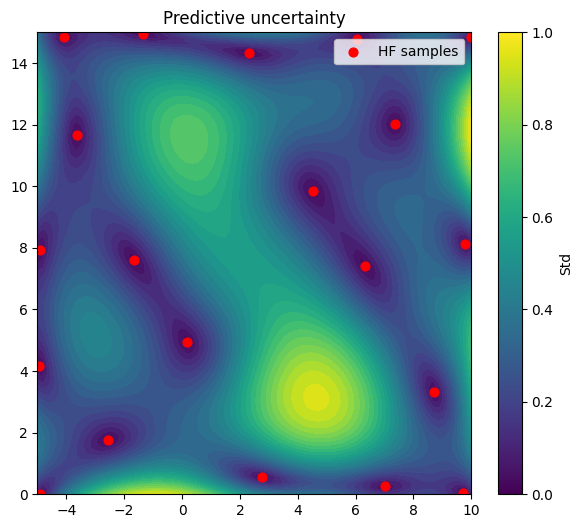

In [6]:
evaluation = evaluator.evaluate(surrogate_final)

print("MSE:",evaluation["mse"])
print("RMSE:",evaluation["rmse"])
print("MAE:",evaluation["mae"])

plotter = ActiveLearningPlotter(problem, evaluator)
plotter.plot_uncertainty(evaluation["X_test"],evaluation["std"],dataset_final.X)

# Example 2: Active Learning Cohn

In [8]:
problem = Branin() 

design = LHS(n_points=10)
dataset = design.generate(problem)

surrogate = GaussianProcess()

## Active Learning Cohn (ALC)

Diversamente dalla strategia ALM, che sceglie il punto con la massima incertezza locale, il metodo **ALC** adotta una prospettiva globale: seleziona il candidato che, una volta osservato e aggiunto al dataset, garantisce la **massima riduzione media dell'errore di predizione** sull'intero dominio $\mathcal{X}$.

Formualmente, l'ALC minimizza la varianza predittiva globale integrata del Processo Gaussiano:

$$
x_{n+1} = \arg\min_{x'} \int_{\mathcal{X}} \sigma_{n+1}^{2}(x; x') \, dx
$$

dove $\sigma_{n+1}^{2}(x; x') = \text{Var}\left(f(x) \mid f(x_1), \dots, f(x_n), f(x')\right)$ rappresenta la varianza predittiva aggiornata nel punto $x$ ipotizzando di aver aggiunto il nuovo punto candidato $x'$.

Calcolando l'impatto di ciascun candidato sull'incertezza residua media dell'intero spazio, l'ALC tende a bilanciare l'esplorazione e ad evitare il sovracampionamento sbilanciato sui bordi.

In [9]:
acquisition = alcSampling(problem=problem, n_integration_points=500)
candidate_generator = LHSCandidateGenerator(n_points=1000)

In [10]:
evaluator = SurrogateEvaluator(
    problem,
    n_grid=80,
    seed=42
)

experiment = Experiment(
    problem,
    dataset,
    surrogate,
    acquisition,
    candidate_generator,
    evaluator,
    budget=10
)

In [11]:
result = experiment.run()

surrogate_final = result["surrogate"]
dataset_final = result["dataset"]
history = result["history"]

MSE: 435.40991862055233
RMSE: 20.866478347353016
MAE: 11.347977751345924


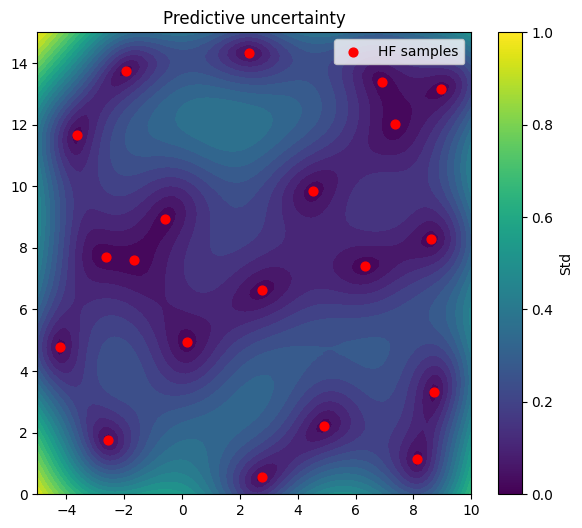

In [12]:
evaluation = evaluator.evaluate(surrogate_final)

print("MSE:",evaluation["mse"])
print("RMSE:",evaluation["rmse"])
print("MAE:",evaluation["mae"])

plotter = ActiveLearningPlotter(problem, evaluator)
plotter.plot_uncertainty(evaluation["X_test"],evaluation["std"],dataset_final.X)

### Analisi e Confronto dei Risultati

Dall'analisi delle distribuzioni dei punti campionati si nota chiaramente la differenza strutturale tra i due criteri:
- **ALM** concentra le nuove valutazioni quasi esclusivamente lungo i bordi del dominio, guidato dall'elevata varianza estrapolativa tipica dei Processi Gaussiani alle estremità dello spazio.
- **ALC** distribuisce i punti in modo più omogeneo sia nelle aree interne che intermedie, prevenendo la concentrazione perimetrale e favorendo una riduzione uniforme della varianza predittiva.